# Premier try
## Premier modèle : Random Foresy + exploration + mise en place d'une métrique coût métier
## Modèle sélectionné --> voir lightGBM.ipynb

In [27]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore') ## utile!

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import recall_score, precision_score

from sklearn.model_selection import StratifiedKFold

In [10]:
## chargement des données 
df = pd.read_csv('data/train_engineered.csv')

X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

print('Shape X :', X.shape)
print('Distribution TARGET :\n', y.value_counts())

Shape X : (307511, 396)
Distribution TARGET :
 TARGET
0.0    282686
1.0     24825
Name: count, dtype: int64


In [ ]:
## nettoyage des infinis (produits par les agregations dans kernel2)
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))
print('Infinis restants :', np.isinf(X.select_dtypes('number').values).sum())

Infinis restants : 0


In [12]:
## train/test
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train :', X_train.shape)
print('Val   :', X_val.shape)

Train : (246008, 396)
Val   : (61503, 396)


In [ ]:
## On paramètre ML Flow pour notre usage :
mlflow.set_tracking_uri('sqlite:///mlflow.db')  
mlflow.set_experiment('home-credit-scoring')

mlflow.sklearn.autolog(
    log_models=False,
    log_input_examples=False,
    log_model_signatures=False
)

## Modèle 1

In [40]:
# Entrainement avec MLFlow sur une RandomForest
mlflow.set_experiment('home-credit-scoring')

params = {
    'n_estimators' : 100,
    'max_depth'    : 5,
    'class_weight' : 'balanced',
    'random_state' : 42,
    'n_jobs'       : -1,
}

mlflow.sklearn.autolog(
    log_models=False,
    log_input_examples=False,
    log_model_signatures=False
)

with mlflow.start_run(run_name='random_forest_class_weight',
                      tags={'type': 'class_weight'},
                      description='RandomForest avec class_weight=balanced pour gérer le déséquilibre'):

    # entraînement
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    # validation croisée
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    mlflow.log_metric('cv_auc_mean', cv_scores.mean())
    mlflow.log_metric('cv_auc_std',  cv_scores.std())

    # métriques sur val
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    mlflow.log_metric('auc',          roc_auc_score(y_val, y_pred_proba))
    mlflow.log_metric('avg_precision', average_precision_score(y_val, y_pred_proba))


    print(f'CV AUC      : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'AUC val     : {roc_auc_score(y_val, y_pred_proba):.4f}')
    print(f'Seuil       : {optimal_threshold:.3f}')
    print(f'Recall      : {recall_score(y_val, y_pred, pos_label=1):.3f}')
    print(f'Précision   : {precision_score(y_val, y_pred, pos_label=1):.3f}')


CV AUC      : 0.7257 ± 0.0012
AUC val     : 0.7300
Seuil       : 0.618
Recall      : 0.123
Précision   : 0.300


In [ ]:
## On lance l'interface MLFlow avec uv run mlflow ui
## On l'ouvre dans http://localhost:5000

## Modèle 2

On tente d'améliorer le recall du modèle en adoptant un seuil métier et on ajoute une métrique métier.

In [41]:
# On choisit un seuil adapté 
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)

couts = []
for threshold in thresholds:
    y_pred_t = (y_pred_proba > threshold).astype(int)
    fn_t = ((y_pred_t == 0) & (y_val == 1)).sum()
    fp_t = ((y_pred_t == 1) & (y_val == 0)).sum()
    couts.append(10 * fn_t + fp_t)

optimal_threshold = thresholds[np.argmin(couts)]



In [42]:
# On rajoute un coût/métier personnalisé 
## Je suppose que ne pas détecter quelqu'un d'insolvable est plus grave que de détecter 
# quelqu'un insolvable à tord 
## cout d'un FN > FP : on estime que cout(FN)=10.cout(FP)
y_pred = (y_pred_proba > optimal_threshold).astype(int)

def cout_metier(y_true, y_pred, cout_fn=10, cout_fp=1):
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    return cout_fn * fn + cout_fp * fp

cout      = cout_metier(y_val, y_pred)
cout_naif = cout_metier(y_val, np.zeros(len(y_val)).astype(int))
ratio_vs_naif = cout / cout_naif

print(f'Seuil optimal   : {optimal_threshold:.3f}')
print(f'Coût modèle     : {cout}')
print(f'Coût naïf       : {cout_naif}')
print(f'Ratio vs naïf   : {ratio_vs_naif:.3f}')
print(f'Le modèle coûte {ratio_vs_naif:.0%} du coût d\'un modèle qui ne détecte rien.')


Seuil optimal   : 0.507
Coût modèle     : 34640
Coût naïf       : 49650
Ratio vs naïf   : 0.698
Le modèle coûte 70% du coût d'un modèle qui ne détecte rien.


In [ ]:
### On check le modèle avec ce nouveau seuil (et avec la nouvelle métrique) :

def cout_metier(y_true, y_pred, cout_fn=10, cout_fp=1):
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    return cout_fn * fn + cout_fp * fp

params = {
    'n_estimators' : 100,
    'max_depth'    : 5,
    'class_weight' : 'balanced',
    'random_state' : 42,
    'n_jobs'       : -1,
}

mlflow.sklearn.autolog(
    log_models=False,
    log_input_examples=False,
    log_model_signatures=False
)


with mlflow.start_run(run_name='random_forest_seuil',
                      tags={'type': 'class_weight', 'seuil': 'optimise_cout_metier'},
                      description='RandomForest avec class_weight=balanced, seuil optimisé sur coût métier FN=10.FP'):
    # entraînement
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    # validation croisée stratifiée
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    mlflow.log_metric('cv_auc_mean', cv_scores.mean())
    mlflow.log_metric('cv_auc_std',  cv_scores.std())

    # probabilités sur val
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    mlflow.log_metric('auc',           roc_auc_score(y_val, y_pred_proba))
    mlflow.log_metric('avg_precision', average_precision_score(y_val, y_pred_proba))

    # seuil optimal basé sur le coût métier
    fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
    couts = []
    for threshold in thresholds:
        y_pred_t = (y_pred_proba > threshold).astype(int)
        couts.append(cout_metier(y_val, y_pred_t))
    optimal_threshold = thresholds[np.argmin(couts)]
    mlflow.log_param('seuil_optimal', round(float(optimal_threshold), 3))

    # métriques au seuil optimal
    y_pred = (y_pred_proba > optimal_threshold).astype(int)
    mlflow.log_metric('recall_minority',    recall_score(y_val, y_pred, pos_label=1))
    mlflow.log_metric('precision_minority', precision_score(y_val, y_pred, pos_label=1))
    mlflow.log_metric('f1',                f1_score(y_val, y_pred, pos_label=1))

    # coût métier
    cout      = cout_metier(y_val, y_pred)
    cout_naif = cout_metier(y_val, np.zeros(len(y_val)).astype(int))
    ratio_vs_naif = cout / cout_naif
    mlflow.log_metric('cout_metier',   cout)
    mlflow.log_metric('ratio_vs_naif', ratio_vs_naif)

    print(f'CV AUC        : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'AUC val       : {roc_auc_score(y_val, y_pred_proba):.4f}')
    print(f'Seuil optimal : {optimal_threshold:.3f}')
    print(f'Recall        : {recall_score(y_val, y_pred, pos_label=1):.3f}')
    print(f'Précision     : {precision_score(y_val, y_pred, pos_label=1):.3f}')
    print(f'Ratio vs naïf : {ratio_vs_naif:.3f}')
    print(f'Le modèle coûte {ratio_vs_naif:.0%} du coût d\'un modèle qui ne détecte rien.')

CV AUC        : 0.7257 ± 0.0012
AUC val       : 0.7300
Seuil optimal : 0.507
Recall        : 0.631
Précision     : 0.161
Ratio vs naïf : 0.698
Le modèle coûte 70% du coût d'un modèle qui ne détecte rien.


On a déjà un recall bien meilleur.

## Modèle 3

In [52]:
# features avec une corrélation > 0.9 (les quasi doublons) avec au moins une autre feature
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

print(f'Features hautement corrélées (>0.9) : {len(to_drop)}')
print(to_drop[:20])  # affiche les 20 premières

Features hautement corrélées (>0.9) : 75
['AMT_GOODS_PRICE', 'FLAG_EMP_PHONE', 'REGION_RATING_CLIENT_W_CITY', 'YEARS_BEGINEXPLUATATION_MODE', 'FLOORSMAX_MODE', 'YEARS_BEGINEXPLUATATION_MEDI', 'FLOORSMAX_MEDI', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DAYS_EMPLOYED_ANOM', 'NAME_CONTRACT_TYPE_Revolving loans', 'CODE_GENDER_M', 'FLAG_OWN_CAR_Y', 'FLAG_OWN_REALTY_Y', 'NAME_INCOME_TYPE_Pensioner', 'ORGANIZATION_TYPE_XNA', 'EMERGENCYSTATE_MODE_No', 'DAYS_EMPLOYED_PERC', 'BURO_AMT_CREDIT_SUM_DEBT_SUM', 'PREV_AMT_CREDIT_MIN', 'PREV_AMT_CREDIT_MAX']


In [58]:
# on les drop 
to_drop_existing = [col for col in to_drop if col in X_train.columns]

X_train = X_train.drop(columns=to_drop_existing)
X_val   = X_val.drop(columns=to_drop_existing)
# on réentraine le modèle en fonction
model.fit(X_train, y_train)

2026/07/26 19:59:58 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'f3f5705683ab42fea38138e0ac1580c3', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_featu

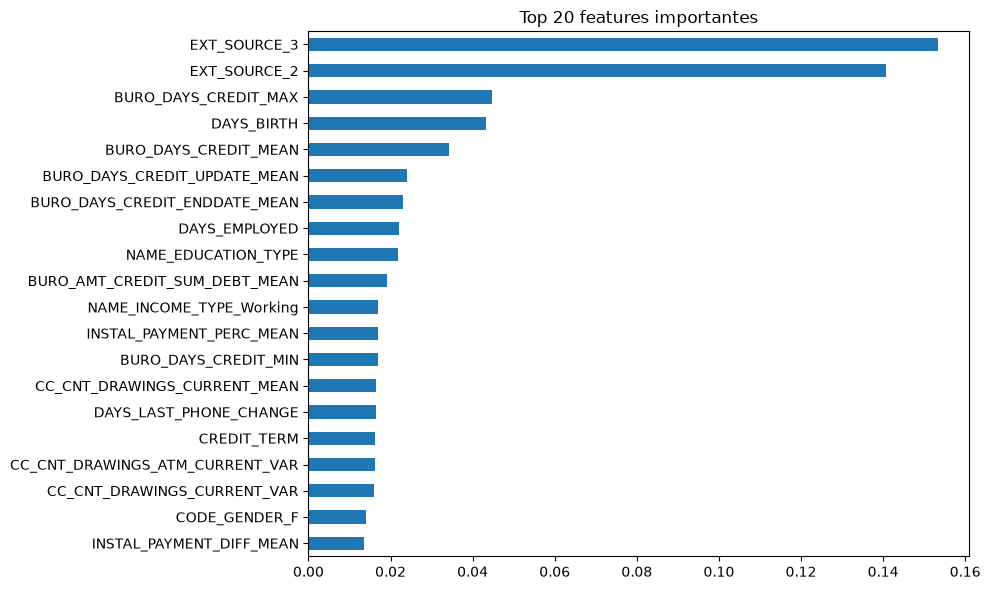

In [59]:
## Feature importance pour sélectionner les features du prochain modèle
importances = pd.Series(model.feature_importances_, index=X_train.columns)
top20 = importances.nlargest(20)

plt.figure(figsize=(10, 6))
top20.sort_values().plot(kind='barh')
plt.title('Top 20 features importantes')
plt.tight_layout()
plt.show()


In [ ]:
# features les moins importantes
importances.nsmallest(50).sort_values()
# il semble en avoir beaucoup...

FLAG_MOBIL                                 0.0
FLAG_WORK_PHONE                            0.0
FLAG_CONT_MOBILE                           0.0
REG_REGION_NOT_LIVE_REGION                 0.0
REG_REGION_NOT_WORK_REGION                 0.0
LIVE_REGION_NOT_WORK_REGION                0.0
LIVE_CITY_NOT_WORK_CITY                    0.0
FLAG_DOCUMENT_2                            0.0
FLAG_DOCUMENT_4                            0.0
FLAG_DOCUMENT_5                            0.0
FLAG_DOCUMENT_7                            0.0
FLAG_DOCUMENT_8                            0.0
FLAG_DOCUMENT_9                            0.0
FLAG_DOCUMENT_10                           0.0
FLAG_DOCUMENT_11                           0.0
FLAG_DOCUMENT_12                           0.0
FLAG_DOCUMENT_13                           0.0
FLAG_DOCUMENT_14                           0.0
FLAG_DOCUMENT_15                           0.0
FLAG_DOCUMENT_16                           0.0
FLAG_DOCUMENT_17                           0.0
FLAG_DOCUMENT

In [ ]:
# Garder uniquement les features utilisées au moins une fois
useful_features = importances[importances > 0].index.tolist()
print(f"Features utiles : {len(useful_features)}")

X_train = X_train[useful_features]
X_val   = X_val[useful_features]

# On réentraîne 
model.fit(X_train, y_train)

Features utiles : 174


2026/07/26 20:07:04 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '0a18de07df7d40d29126526d91b37e9f', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_featu

In [ ]:
## Enfin, on entraine le modèle avec la nouvelle sélection de features : 

with mlflow.start_run(run_name='random_forest_feature_selection',
                      tags={'type': 'feature_selection', 'seuil': 'optimise_cout_metier'},
                      description='RandomForest avec sélection de features : suppression corrélations >0.9 et features à importance nulle'):

    # entraînement sur X nettoyé 
    model3 = RandomForestClassifier(**params)
    model3.fit(X_train, y_train)

    # validation croisée
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model3, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    mlflow.log_metric('cv_auc_mean', cv_scores.mean())
    mlflow.log_metric('cv_auc_std',  cv_scores.std())

    # log du nombre de features
    mlflow.log_param('n_features', X_train.shape[1])

    # probabilités sur val
    y_pred_proba = model3.predict_proba(X_val)[:, 1]
    mlflow.log_metric('auc',           roc_auc_score(y_val, y_pred_proba))
    mlflow.log_metric('avg_precision', average_precision_score(y_val, y_pred_proba))

    # seuil optimal basé sur le coût métier
    fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
    couts = []
    for threshold in thresholds:
        y_pred_t = (y_pred_proba > threshold).astype(int)
        couts.append(cout_metier(y_val, y_pred_t))
    optimal_threshold = thresholds[np.argmin(couts)]
    mlflow.log_param('seuil_optimal', round(float(optimal_threshold), 3))

    # métriques au seuil optimal
    y_pred = (y_pred_proba > optimal_threshold).astype(int)
    mlflow.log_metric('recall_minority',    recall_score(y_val, y_pred, pos_label=1))
    mlflow.log_metric('precision_minority', precision_score(y_val, y_pred, pos_label=1))
    mlflow.log_metric('f1',                f1_score(y_val, y_pred, pos_label=1))

    # coût métier
    cout      = cout_metier(y_val, y_pred)
    cout_naif = cout_metier(y_val, np.zeros(len(y_val)).astype(int))
    ratio_vs_naif = cout / cout_naif
    mlflow.log_metric('cout_metier',   cout)
    mlflow.log_metric('ratio_vs_naif', ratio_vs_naif)

    print(f'CV AUC        : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'AUC val       : {roc_auc_score(y_val, y_pred_proba):.4f}')
    print(f'Seuil optimal : {optimal_threshold:.3f}')
    print(f'Recall        : {recall_score(y_val, y_pred, pos_label=1):.3f}')
    print(f'Précision     : {precision_score(y_val, y_pred, pos_label=1):.3f}')
    print(f'Ratio vs naïf : {ratio_vs_naif:.3f}')
    print(f'Le modèle coûte {ratio_vs_naif:.0%} du coût d\'un modèle qui ne détecte rien.')


# C'est un peu mieux niveau métier.

CV AUC        : 0.7291 ± 0.0019
AUC val       : 0.7342
Seuil optimal : 0.501
Recall        : 0.668
Précision     : 0.156
Ratio vs naïf : 0.694
Le modèle coûte 69% du coût d'un modèle qui ne détecte rien.
